### Problem Statement
Brain tumor detection is a critical medical task. Early detection can save lives and improve treatment outcomes. My goal is to classify MRI images into four categories: 
- Glioma
- Meningioma
- Pituitary
- No Tumor

**Beneficiaries:** 
Doctors, radiologists, and patients can use this model to quickly identify tumor types from MRI scans.

**Dataset:** Brain Tumor Classification MRI from Kaggle 
https://www.kaggle.com/datasets/sartajbhuvaji/brain-tumor-classification-mri
- Total images: ~3000  
- Classes: Glioma (~826), Meningioma (~822), Pituitary (~827), No Tumor (~395)  

**Features:** Image data
**Target Variables:** Tumor type

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sartajbhuvaji/brain-tumor-classification-mri")

print("Path to dataset files:", path)

d:\Machine Learing cause\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\kavee\.cache\kagglehub\datasets\sartajbhuvaji\brain-tumor-classification-mri\versions\3


## Importing libraries

In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Part 1 - Data preprocessing

## preprocessing the training data

In [4]:
train_datagen = ImageDataGenerator(rescale=1./255, shear_range=0.2, zoom_range=0.2, horizontal_flip=True)
training_set = train_datagen.flow_from_directory('dataset/Training', target_size=(64, 64), batch_size=32, class_mode='categorical')  

Found 2870 images belonging to 4 classes.


## preprocessing the test data

In [5]:
test_datagen = ImageDataGenerator(rescale=1./255)
test_set = test_datagen.flow_from_directory('dataset/Testing', target_size=(64, 64), batch_size=32, class_mode='categorical')

Found 394 images belonging to 4 classes.


## Data visualization

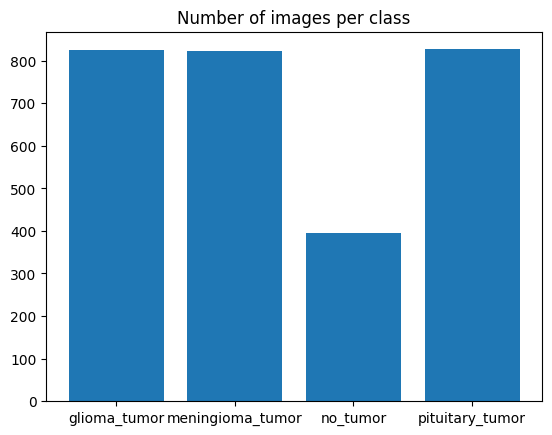

In [6]:
import matplotlib.pyplot as plt
import os

classes = list(training_set.class_indices.keys())
counts = [len(os.listdir(f'dataset/Training/{c}')) for c in classes]

plt.bar(classes, counts)
plt.title("Number of images per class")
plt.show()

# Part 2 - Building the CNN

## Initializing the CNN

In [7]:
cnn = tf.keras.models.Sequential()

## Step 1 - convolution

In [8]:
cnn.add(tf.keras.layers.Conv2D(filters=32, kernel_size=3, activation='relu', input_shape=[64, 64, 3]))

d:\Machine Learing cause\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Step 2 - pooling

In [9]:
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2, strides=2))

## Adding the second convolutional layer

In [10]:
cnn.add(tf.keras.layers.Conv2D(filters=32, kernel_size=3, activation='relu', input_shape=[64, 64, 3]))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2, strides=2))

## Adding the third convolutional layer

In [11]:
cnn.add(tf.keras.layers.Conv2D(filters=32, kernel_size=3, activation='relu', input_shape=[64, 64, 3]))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2, strides=2))

## step 3 - flatterining

In [12]:
cnn.add(tf.keras.layers.Flatten())

## step 4 - full connection

In [13]:
cnn.add(tf.keras.layers.Dense(units=128, activation='relu'))

## step 5 - output layer

In [14]:
cnn.add(tf.keras.layers.Dense(units=4, activation='softmax'))

# Part 3 - Training the CNN

## Compiling the CNN

In [15]:
cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

## Training the CNN on the training set and evaluate it on the test set

In [17]:
cnn.fit(x=training_set, validation_data=test_set, epochs=25)

Epoch 1/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 137s 1s/step - accuracy: 0.4495 - loss: 1.2073 - val_accuracy: 0.2690 - val_loss: 1.8753
Epoch 2/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 11s 124ms/step - accuracy: 0.6059 - loss: 0.9367 - val_accuracy: 0.3325 - val_loss: 1.8239
Epoch 3/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 11s 125ms/step - accuracy: 0.6700 - loss: 0.7971 - val_accuracy: 0.4264 - val_loss: 1.8177
Epoch 4/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 11s 127ms/step - accuracy: 0.7070 - loss: 0.7047 - val_accuracy: 0.4721 - val_loss: 1.7288
Epoch 5/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 12s 130ms/step - accuracy: 0.7523 - loss: 0.6146 - val_accuracy: 0.4873 - val_loss: 2.0011
Epoch 6/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 12s 129ms/step - accuracy: 0.7746 - loss: 0.5664 - val_accuracy: 0.5051 - val_loss: 1.9470
Epoch 7/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 11s 123ms/step - accuracy: 0.7934 - loss: 0.5263 - val_accuracy: 0.5152 - val_loss: 1.7124
Epoch 8/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 14s 159ms/step - accuracy: 0.8139 - loss: 0.4812 - val_accura

## Training/Validation plots for accuracy & loss

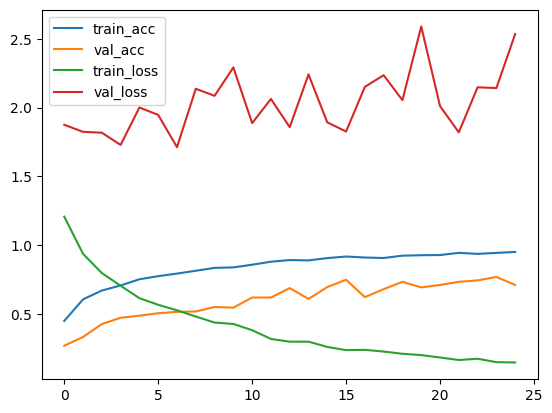

In [18]:
plt.plot(cnn.history.history['accuracy'], label='train_acc')
plt.plot(cnn.history.history['val_accuracy'], label='val_acc')
plt.plot(cnn.history.history['loss'], label='train_loss')
plt.plot(cnn.history.history['val_loss'], label='val_loss')
plt.legend()
plt.show()

## Confusion matrix

In [19]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

pred = cnn.predict(test_set)
pred_classes = np.argmax(pred, axis=1)
true_classes = test_set.classes
print(classification_report(true_classes, pred_classes, target_names=classes))

13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 237ms/step
                  precision    recall  f1-score   support

    glioma_tumor       0.18      0.04      0.07       100
meningioma_tumor       0.27      0.37      0.31       115
        no_tumor       0.24      0.38      0.30       105
 pituitary_tumor       0.18      0.11      0.13        74

        accuracy                           0.24       394
       macro avg       0.22      0.23      0.20       394
    weighted avg       0.22      0.24      0.21       394



## Save the model

In [20]:
cnn.save('model/brain_model.h5')

# Part 4

## Second model 

In [21]:
from tensorflow.keras.applications import VGG16

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(64,64,3))
# Freeze base model
for layer in base_model.layers:
    layer.trainable = False

model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(4, activation='softmax')
])

In [22]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [23]:
history_vgg = model.fit(x=training_set, validation_data=test_set, epochs=25)

Epoch 1/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 70s 711ms/step - accuracy: 0.6007 - loss: 0.9275 - val_accuracy: 0.4594 - val_loss: 1.5024
Epoch 2/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 56s 623ms/step - accuracy: 0.7300 - loss: 0.6778 - val_accuracy: 0.4721 - val_loss: 1.6092
Epoch 3/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 55s 611ms/step - accuracy: 0.7564 - loss: 0.5995 - val_accuracy: 0.5533 - val_loss: 1.4358
Epoch 4/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 53s 590ms/step - accuracy: 0.7774 - loss: 0.5630 - val_accuracy: 0.5431 - val_loss: 1.5613
Epoch 5/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 68s 753ms/step - accuracy: 0.7822 - loss: 0.5372 - val_accuracy: 0.5584 - val_loss: 1.7529
Epoch 6/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 54s 601ms/step - accuracy: 0.8084 - loss: 0.4993 - val_accuracy: 0.6015 - val_loss: 1.6329
Epoch 7/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 104s 1s/step - accuracy: 0.8087 - loss: 0.4824 - val_accuracy: 0.6066 - val_loss: 1.5135
Epoch 8/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 94s 1s/step - accuracy: 0.8202 - loss: 0.4534 - val_accuracy:

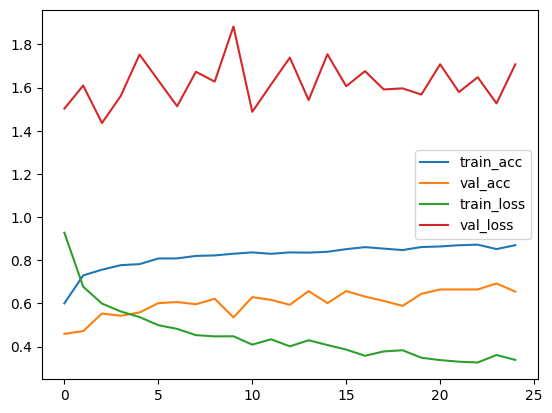

In [24]:
plt.plot(model.history.history['accuracy'], label='train_acc')
plt.plot(model.history.history['val_accuracy'], label='val_acc')
plt.plot(model.history.history['loss'], label='train_loss')
plt.plot(model.history.history['val_loss'], label='val_loss')
plt.legend()
plt.show()

In [25]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

pred = model.predict(test_set)
pred_classes = np.argmax(pred, axis=1)
true_classes = test_set.classes
print(classification_report(true_classes, pred_classes, target_names=classes))

13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 621ms/step
                  precision    recall  f1-score   support

    glioma_tumor       0.14      0.04      0.06       100
meningioma_tumor       0.25      0.24      0.25       115
        no_tumor       0.26      0.47      0.33       105
 pituitary_tumor       0.16      0.15      0.15        74

        accuracy                           0.23       394
       macro avg       0.20      0.22      0.20       394
    weighted avg       0.21      0.23      0.21       394

